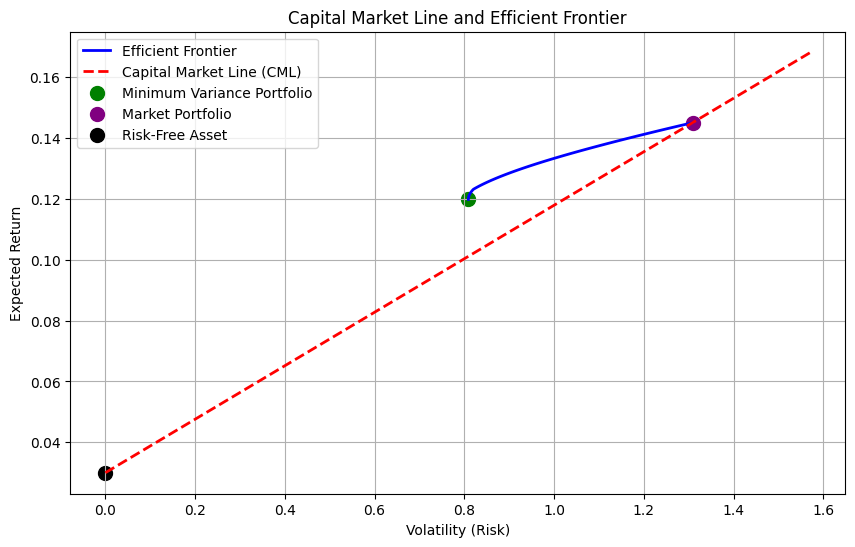

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco

# Simulating random asset returns and covariance matrix
np.random.seed(42)
num_assets = 5
mean_returns = np.random.uniform(0.05, 0.15, num_assets)  # Expected returns
cov_matrix = np.random.rand(num_assets, num_assets)
cov_matrix = np.dot(cov_matrix, cov_matrix.T)  # Ensuring it's positive semi-definite

# Risk-free rate
rf_rate = 0.03

# Function to calculate portfolio performance
def portfolio_performance(weights, mean_returns, cov_matrix):
    port_return = np.dot(weights, mean_returns)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_volatility

# Function to minimize for efficient frontier (minimum variance)
def min_variance(weights, mean_returns, cov_matrix):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]

# Constraints and bounds
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}  # Sum of weights = 1
bounds = tuple((0, 1) for _ in range(num_assets))  # No short-selling

# Finding the minimum variance portfolio
num_assets = len(mean_returns)
init_guess = num_assets * [1. / num_assets]
opt_min_var = sco.minimize(min_variance, init_guess, args=(mean_returns, cov_matrix),
                           method='SLSQP', bounds=bounds, constraints=constraints)

min_vol_weights = opt_min_var.x
min_vol_return, min_vol_volatility = portfolio_performance(min_vol_weights, mean_returns, cov_matrix)

# Generating the efficient frontier
target_returns = np.linspace(min_vol_return, max(mean_returns), 100)
efficient_frontier = []

for ret in target_returns:
    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1},  # Weights sum to 1
                   {'type': 'eq', 'fun': lambda x: np.dot(x, mean_returns) - ret}]  # Target return constraint
    opt_portfolio = sco.minimize(min_variance, init_guess, args=(mean_returns, cov_matrix),
                                 method='SLSQP', bounds=bounds, constraints=constraints)
    efficient_frontier.append(portfolio_performance(opt_portfolio.x, mean_returns, cov_matrix)[1])

# Finding the tangency portfolio (Market Portfolio)
def sharpe_ratio(weights, mean_returns, cov_matrix, rf_rate):
    port_return, port_volatility = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(port_return - rf_rate) / port_volatility  # Negative for minimization

opt_tangency = sco.minimize(sharpe_ratio, init_guess, args=(mean_returns, cov_matrix, rf_rate),
                            method='SLSQP', bounds=bounds, constraints=constraints)

market_weights = opt_tangency.x
market_return, market_volatility = portfolio_performance(market_weights, mean_returns, cov_matrix)

# Plotting the Capital Market Line (CML)
cml_x = np.linspace(0, max(efficient_frontier) * 1.2, 100)
cml_y = rf_rate + (market_return - rf_rate) / market_volatility * cml_x

# Plotting the Efficient Frontier and CML
plt.figure(figsize=(10, 6))
plt.plot(efficient_frontier, target_returns, label="Efficient Frontier", color='blue', linewidth=2)
plt.plot(cml_x, cml_y, label="Capital Market Line (CML)", linestyle="--", color="red", linewidth=2)

# Marking specific points
plt.scatter(min_vol_volatility, min_vol_return, color='green', marker='o', s=100, label="Minimum Variance Portfolio")
plt.scatter(market_volatility, market_return, color='purple', marker='o', s=100, label="Market Portfolio")
plt.scatter(0, rf_rate, color='black', marker='o', s=100, label="Risk-Free Asset")

# Labels and legend
plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")
plt.title("Capital Market Line and Efficient Frontier")
plt.legend()
plt.grid(True)
plt.show()
